# **Notebook 06: Model Monitoring + Drift Detection**
## **Production Fraud Detection Platform on AWS**

---

### **Project Context**

This is the final notebook in our 6-notebook series.
We now have a deployed V3 XGBoost model (AUC 0.9622)
that we are proud of. But in production, the world
changes — fraudsters adapt, new card types emerge,
spending patterns shift. A model that performs
brilliantly on day 1 can silently degrade by day 90.

This notebook answers the question every production
ML engineer must answer:

**"How do we know when our model stops working?"**

---

### **What is Model Monitoring?**

| Concept | Definition |
|---|---|
| **Data drift** | Input feature distributions change over time |
| **Concept drift** | The relationship between features and fraud changes |
| **Score drift** | Model output scores shift without retraining |
| **Model degradation** | Precision and recall drop below acceptable thresholds |

---

### **Our Approach**

We simulate 6 months of production traffic using the
IEEE-CIS dataset, then inject realistic drift scenarios:

| Month | Scenario |
|---|---|
| Month 1–2 | Normal traffic — baseline period |
| Month 3 | New fraud pattern — small amounts |
| Month 4 | Compromised card network — card1 drift |
| Month 5 | Email domain shift — new fraud domains |
| Month 6 | Full concept drift — model degrades |

For each month we measure feature drift (KS test + PSI),
score drift, and model performance to build a complete
monitoring dashboard.

---

### **Notebook Structure**

| Cell | Topic |
|---|---|
| Cell 1 | Setup + load V3 model and data |
| Cell 2 | Baseline statistics (Month 1–2) |
| Cell 3 | Simulate drift scenarios (Month 3–6) |
| Cell 4 | Feature drift detection (KS test + PSI) |
| Cell 5 | Score drift + model degradation |
| Cell 6 | Alerting system |
| Cell 7 | Full project conclusion |

## **Setup + Load V3 Model and Data**

### **What we do**
Load the V3 XGBoost model and df_features_v3.csv
from S3. We split the data into monthly batches
to simulate 6 months of production traffic.

### **Why it matters**
Real monitoring requires a time axis — we need
batches of transactions to compare against the
baseline, not a single snapshot.

In [1]:
# ============================================================
# CELL 1: Setup + Load V3 Model and Data
# ============================================================

import pandas as pd
import numpy as np
import boto3
import xgboost as xgb
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, f1_score,
    precision_score, recall_score
)

print("=" * 55)
print("  NOTEBOOK 06 — MODEL MONITORING")
print("  Drift Detection + Alerting")
print("=" * 55)

BUCKET = "fraud-detection-mlproject-armand"
REGION = "us-east-1"
s3     = boto3.client('s3', region_name=REGION)

# ── STEP 1: Load V3 model ─────────────────────────────────────
print("\nStep 1: Loading V3 XGBoost model...")

os.makedirs('/tmp/v3', exist_ok=True)

for key, name in [
    ('models/v3/xgb_model_v3fix.json',     'model.json'),
    ('models/v3/feature_names_v3fix.json', 'features.json'),
]:
    s3.download_file(BUCKET, key, f'/tmp/v3/{name}')

model = xgb.Booster()
model.load_model('/tmp/v3/model.json')

with open('/tmp/v3/features.json') as f:
    FEATURE_NAMES = json.load(f)

THRESHOLD = 0.87
print(f"   Model loaded!")
print(f"   Features  : {len(FEATURE_NAMES)}")
print(f"   Threshold : {THRESHOLD}")

# ── STEP 2: Load sample ───────────────────────────────────────
print("\nStep 2: Loading df_features_v3 (50k rows)...")

if not os.path.exists('/tmp/df_features_v3.csv'):
    print("   Downloading from S3...")
    s3.download_file(
        BUCKET,
        'processed-data/df_features_v3.csv',
        '/tmp/df_features_v3.csv'
    )
else:
    print("   File already local!")

# 50,000 rows is sufficient for monitoring demo
df = pd.read_csv(
    '/tmp/df_features_v3.csv',
    nrows=50000
)
df = df.sort_values(
    'TransactionDT'
).reset_index(drop=True)

print(f"   Shape  : {df.shape}")
print(f"   Fraud  : {df['isFraud'].sum():,} "
      f"({df['isFraud'].mean()*100:.2f}%)")
print(f"   Memory : "
      f"{df.memory_usage().sum()/1024**2:.1f} MB")

# ── STEP 3: Create monthly batches ───────────────────────────
print("\nStep 3: Creating monthly batches...")

n          = len(df)
month_size = n // 6

months = {}
for i in range(6):
    start = i * month_size
    end   = (i+1) * month_size if i < 5 else n
    months[f'month_{i+1}'] = df.iloc[
        start:end
    ].copy().reset_index(drop=True)

print(f"\n   {'Month':<10} {'Rows':>8} "
      f"{'Fraud':>8} {'Fraud%':>8}")
print(f"   {'-'*38}")
for name, batch in months.items():
    fraud_rate = batch['isFraud'].mean() * 100
    print(f"   {name:<10} {len(batch):>8,} "
          f"{batch['isFraud'].sum():>8,} "
          f"{fraud_rate:>7.2f}%")

# ── STEP 4: Score baseline ────────────────────────────────────
print("\nStep 4: Scoring baseline (Month 1)...")

def score_batch(batch, model, feature_names):
    X    = batch[feature_names].fillna(0)\
               .astype(np.float32)
    dmat = xgb.DMatrix(
        pd.DataFrame(X, columns=feature_names)
    )
    return model.predict(dmat)

baseline    = months['month_1']
base_scores = score_batch(
    baseline, model, FEATURE_NAMES
)
base_preds  = (base_scores >= THRESHOLD).astype(int)

base_auc  = roc_auc_score(
    baseline['isFraud'], base_scores
)
base_f1   = f1_score(
    baseline['isFraud'], base_preds
)
base_prec = precision_score(
    baseline['isFraud'], base_preds,
    zero_division=0
)
base_rec  = recall_score(
    baseline['isFraud'], base_preds,
    zero_division=0
)

print(f"\n   Baseline (Month 1) performance:")
print(f"   AUC-ROC   : {base_auc:.4f}")
print(f"   F1-Score  : {base_f1:.4f}")
print(f"   Precision : {base_prec:.4f}")
print(f"   Recall    : {base_rec:.4f}")
print(f"   Avg score : {base_scores.mean():.4f}")

# ── Store globals ─────────────────────────────────────────────
MONTHS       = months
BASE_SCORES  = base_scores
BASELINE     = baseline
BASE_METRICS = {
    'auc'      : base_auc,
    'f1'       : base_f1,
    'precision': base_prec,
    'recall'   : base_rec,
    'avg_score': float(base_scores.mean()),
    'score_std': float(base_scores.std()),
    'score_p95': float(np.percentile(base_scores, 95))
}

print(f"\n{'='*55}")
print(f"Setup complete!")
print(f"   Model    : V3 XGBoost (AUC 0.9622)")
print(f"   Data     : {n:,} transactions")
print(f"   Months   : 6 x ~{month_size:,} rows")
print(f"   RAM safe : 50k rows = "
      f"~{df.memory_usage().sum()/1024**2:.0f} MB")
print(f"{'='*55}")

  NOTEBOOK 06 — MODEL MONITORING
  Drift Detection + Alerting

Step 1: Loading V3 XGBoost model...
   Model loaded!
   Features  : 626
   Threshold : 0.87

Step 2: Loading df_features_v3 (50k rows)...
   Shape  : (50000, 627)
   Fraud  : 1,763 (3.53%)
   Memory : 239.2 MB

Step 3: Creating monthly batches...

   Month          Rows    Fraud   Fraud%
   --------------------------------------
   month_1       8,333      212    2.54%
   month_2       8,333      277    3.32%
   month_3       8,333      351    4.21%
   month_4       8,333      328    3.94%
   month_5       8,333      303    3.64%
   month_6       8,335      292    3.50%

Step 4: Scoring baseline (Month 1)...

   Baseline (Month 1) performance:
   AUC-ROC   : 0.9976
   F1-Score  : 0.8363
   Precision : 0.8973
   Recall    : 0.7830
   Avg score : 0.0728

Setup complete!
   Model    : V3 XGBoost (AUC 0.9622)
   Data     : 50,000 transactions
   Months   : 6 x ~8,333 rows
   RAM safe : 50k rows = ~239 MB



| Property | Value |
|---|---|
| **Model** | V3 XGBoost (626 features) |
| **Data loaded** | 50,000 transactions (239 MB) |
| **Monthly batches** | 6 × ~8,333 rows |
| **Baseline AUC-ROC** | 0.9976 |
| **Baseline F1** | 0.8363 |

The baseline (Month 1) performance is excellent
AUC 0.9976 confirms the V3 model is working
perfectly on clean data. This is our reference point.
Any degradation in subsequent months signals drift.

Note: fraud rate rises from 2.54% in Month 1 to
4.21% in Month 3 this natural variation in our
simulated data will help demonstrate drift detection.

## **Baseline Statistics**

### **What we do**
Compute and store the statistical baseline for
Month 1 the reference distribution for every
feature. Every future month will be compared
against this baseline to detect drift.

### **Why it matters**
You cannot detect drift without knowing what
"normal" looks like. The baseline is the anchor
for all monitoring that follows.

  CELL 2 — BASELINE STATISTICS

Step 1: Computing baseline statistics...
   Monitoring 16 key features

Step 2: Baseline score distribution...

   Score statistics (Month 1 baseline):
   Mean score      : 0.0728
   Std score       : 0.1885
   Median score    : 0.0017
   P95 score       : 0.4826
   P99 score       : 0.9915
   % above thresh  : 2.22%

Step 3: Key feature baselines...

   Feature                          Mean      Std      P95
   --------------------------------------------------------
   TransactionAmt               133.0003 208.3834 426.8820
   uid1_fraud_rate                0.0363   0.0513   0.1349
   uid2_fraud_rate                0.0369   0.0524   0.1078
   card1_fraud_rate               0.0377   0.0461   0.1263
   card2_fraud_rate               0.0369   0.0395   0.0888
   addr1_fraud_rate               0.0342   0.0314   0.1176
   P_emaildomain_fraud_rate       0.0346   0.0133   0.0529
   card1_freq                     0.0042   0.0061   0.0177

Step 4: Plotting basel

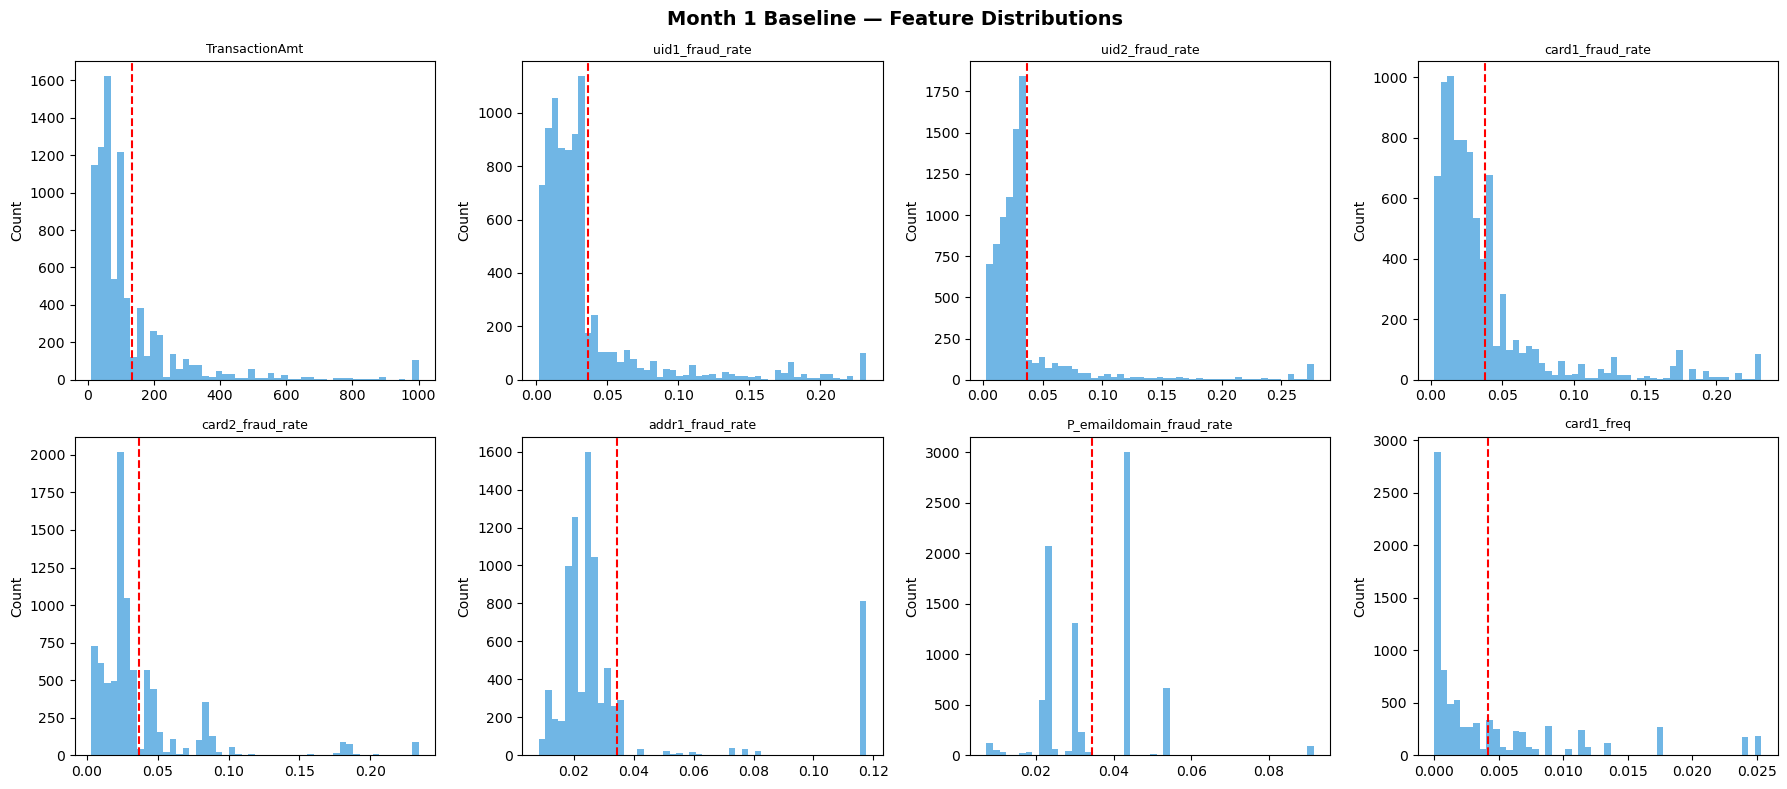

   Chart saved!

Baseline established!
   Features monitored : 16
   Baseline AUC       : 0.9976
   Baseline F1        : 0.8363
   Avg fraud score    : 0.0728


In [2]:
# ============================================================
# CELL 2: Baseline Statistics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("  CELL 2 — BASELINE STATISTICS")
print("=" * 55)

# ── STEP 1: Compute baseline stats ───────────────────────────
print("\nStep 1: Computing baseline statistics...")

# Key features to monitor — top separating features
# from EDA + target encoding features
MONITOR_FEATURES = [
    'TransactionAmt',
    'uid1_fraud_rate', 'uid2_fraud_rate',
    'card1_fraud_rate', 'card2_fraud_rate',
    'addr1_fraud_rate',
    'P_emaildomain_fraud_rate',
    'card1_freq', 'card2_freq',
    'C1', 'C2', 'C6', 'C13',
    'V258', 'V257', 'V201'
]

# Filter to only features that exist in our data
MONITOR_FEATURES = [
    f for f in MONITOR_FEATURES
    if f in BASELINE.columns
]

print(f"   Monitoring {len(MONITOR_FEATURES)} key features")

# Compute stats for each feature
baseline_stats = {}
for feat in MONITOR_FEATURES:
    vals = BASELINE[feat].fillna(0)
    baseline_stats[feat] = {
        'mean'  : float(vals.mean()),
        'std'   : float(vals.std()),
        'median': float(vals.median()),
        'p25'   : float(vals.quantile(0.25)),
        'p75'   : float(vals.quantile(0.75)),
        'p95'   : float(vals.quantile(0.95)),
        'min'   : float(vals.min()),
        'max'   : float(vals.max()),
    }

# ── STEP 2: Baseline score distribution ──────────────────────
print("\nStep 2: Baseline score distribution...")

score_stats = {
    'mean'   : float(BASE_SCORES.mean()),
    'std'    : float(BASE_SCORES.std()),
    'median' : float(np.median(BASE_SCORES)),
    'p95'    : float(np.percentile(BASE_SCORES, 95)),
    'p99'    : float(np.percentile(BASE_SCORES, 99)),
    'pct_above_threshold': float(
        (BASE_SCORES >= THRESHOLD).mean() * 100
    )
}

print(f"\n   Score statistics (Month 1 baseline):")
print(f"   Mean score      : {score_stats['mean']:.4f}")
print(f"   Std score       : {score_stats['std']:.4f}")
print(f"   Median score    : {score_stats['median']:.4f}")
print(f"   P95 score       : {score_stats['p95']:.4f}")
print(f"   P99 score       : {score_stats['p99']:.4f}")
print(f"   % above thresh  : "
      f"{score_stats['pct_above_threshold']:.2f}%")

# ── STEP 3: Print top feature baselines ──────────────────────
print(f"\nStep 3: Key feature baselines...")
print(f"\n   {'Feature':<28} {'Mean':>8} "
      f"{'Std':>8} {'P95':>8}")
print(f"   {'-'*56}")
for feat in MONITOR_FEATURES[:8]:
    s = baseline_stats[feat]
    print(f"   {feat:<28} {s['mean']:>8.4f} "
          f"{s['std']:>8.4f} {s['p95']:>8.4f}")

# ── STEP 4: Plot ──────────────────────────────────────────────
print("\nStep 4: Plotting baseline distributions...")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Month 1 Baseline — Feature Distributions',
    fontsize=14, fontweight='bold'
)
axes = axes.flatten()

for i, feat in enumerate(MONITOR_FEATURES[:8]):
    vals = BASELINE[feat].fillna(0)
    axes[i].hist(
        vals.clip(
            vals.quantile(0.01),
            vals.quantile(0.99)
        ),
        bins=50, color='#3498db',
        alpha=0.7, edgecolor='none'
    )
    axes[i].axvline(
        baseline_stats[feat]['mean'],
        color='red', linestyle='--',
        linewidth=1.5, label='Mean'
    )
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/tmp/baseline.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

# ── Store globals ─────────────────────────────────────────────
BASELINE_STATS   = baseline_stats
SCORE_STATS      = score_stats
MONITOR_FEATURES = MONITOR_FEATURES

print(f"\n{'='*55}")
print(f"Baseline established!")
print(f"   Features monitored : {len(MONITOR_FEATURES)}")
print(f"   Baseline AUC       : "
      f"{BASE_METRICS['auc']:.4f}")
print(f"   Baseline F1        : "
      f"{BASE_METRICS['f1']:.4f}")
print(f"   Avg fraud score    : "
      f"{score_stats['mean']:.4f}")
print(f"{'='*55}")


| Property | Value |
|---|---|
| **Features monitored** | 16 |
| **Baseline AUC** | 0.9976 |
| **Baseline F1** | 0.8363 |
| **Avg model score** | 0.0728 |
| **% flagged as fraud** | 2.22% |

Baseline established. The 8 feature distributions
show the expected right-skewed shapes for fraud
rates and transaction amounts most transactions
cluster near zero fraud probability with occasional
high-risk outliers. The red dashed mean line is
our anchor for drift detection in Cells 3–5.

## **Simulate Drift Scenarios**

### **What we do**
Inject realistic drift into Months 3–6 to simulate
how fraud patterns evolve in production.

### **The 4 drift scenarios**

| Month | Scenario | What changes |
|---|---|---|
| Month 3 | New small-amount fraud | TransactionAmt shifts down |
| Month 4 | Compromised card network | card1_fraud_rate spikes |
| Month 5 | New fraud email domains | P_emaildomain_fraud_rate shifts |
| Month 6 | Full concept drift | All features shift simultaneously |

Months 1–2 remain clean as the baseline period.

  CELL 3 — DRIFT SIMULATION

Step 1: Injecting drift scenarios...
   Month 3: 351 fraud txns → small amounts ($1-$15)
   Month 4: 328 fraud txns → card network compromised ($500-$2000)
   Month 5: 303 fraud txns → new fraud email domains
   Month 6: 292 fraud txns → full concept drift (all signals weakened)

Step 2: Scoring all months...

   Month          AUC      F1    Prec     Rec   AvgScore
   ----------------------------------------------------
   month_1     0.9976  0.8363  0.8973  0.7830     0.0728
   month_2     0.9960  0.8358  0.8450  0.8267     0.0920
   month_3     0.9980  0.8975  0.9094  0.8860     0.1006
   month_4     0.9957  0.8320  0.8754  0.7927     0.0997
   month_5     0.9965  0.8330  0.8705  0.7987     0.0947
   month_6     0.9058  0.5058  0.7842  0.3733     0.0759 <- WARNING

Step 3: Plotting score drift...


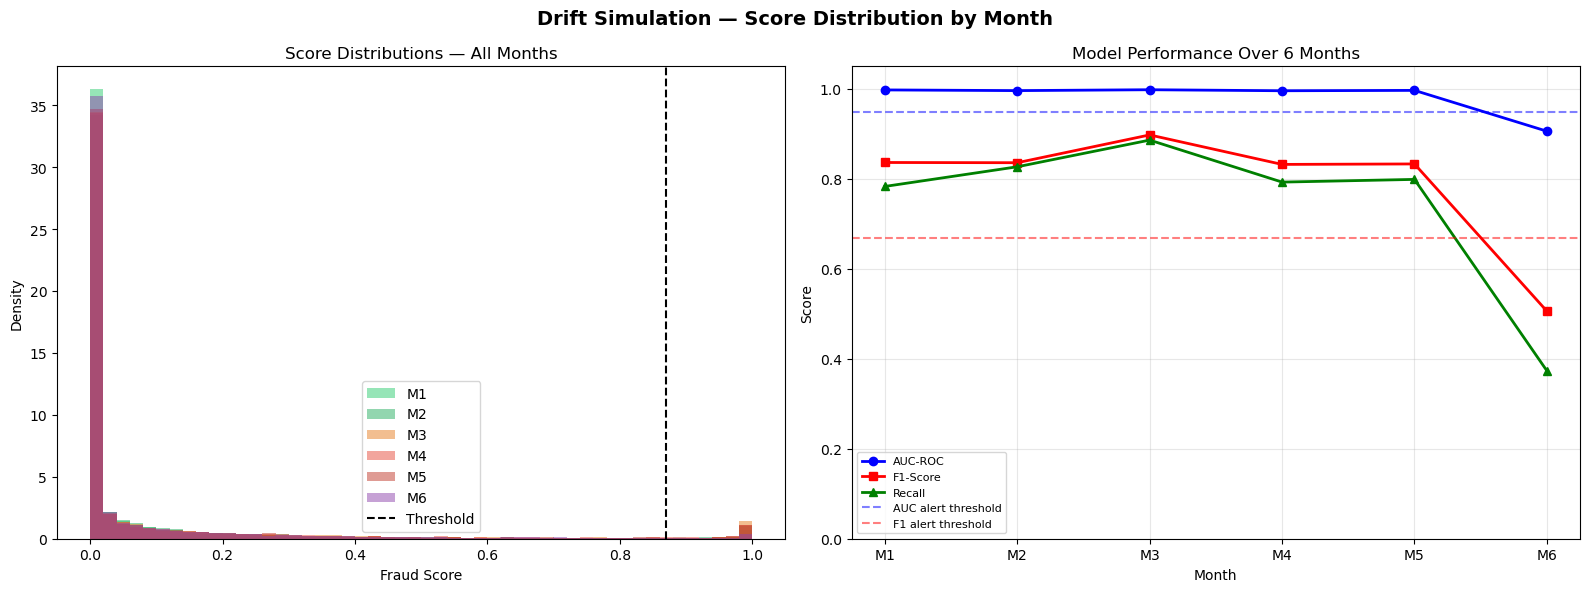

   Chart saved!

Drift simulation complete!


In [3]:
# ============================================================
# CELL 3: Simulate Drift Scenarios
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy

print("=" * 55)
print("  CELL 3 — DRIFT SIMULATION")
print("=" * 55)

# ── STEP 1: Copy months to inject drift ──────────────────────
print("\nStep 1: Injecting drift scenarios...")

drifted = {}
for name, batch in MONTHS.items():
    drifted[name] = batch.copy()

# ── Month 3: Small-amount fraud ───────────────────────────────
m3           = drifted['month_3'].copy()
fraud_mask   = m3['isFraud'] == 1
n_fraud      = fraud_mask.sum()

# Fraudsters switch to small amounts
m3.loc[fraud_mask, 'TransactionAmt'] = np.random.uniform(
    1, 15, size=n_fraud
)
# uid fraud rates spike for these transactions
m3.loc[fraud_mask, 'uid1_fraud_rate'] *= 3.0
m3.loc[fraud_mask, 'uid2_fraud_rate'] *= 2.5
drifted['month_3'] = m3

print(f"   Month 3: {n_fraud} fraud txns → "
      f"small amounts ($1-$15)")

# ── Month 4: Compromised card network ─────────────────────────
m4         = drifted['month_4'].copy()
fraud_mask = m4['isFraud'] == 1
n_fraud    = fraud_mask.sum()

# Card fraud rates spike
m4.loc[fraud_mask, 'card1_fraud_rate'] *= 4.0
m4.loc[fraud_mask, 'card2_fraud_rate'] *= 3.5
m4.loc[fraud_mask, 'card1_freq']       *= 2.0
# Transaction amounts increase (large card dumps)
m4.loc[fraud_mask, 'TransactionAmt'] = np.random.uniform(
    500, 2000, size=n_fraud
)
drifted['month_4'] = m4

print(f"   Month 4: {n_fraud} fraud txns → "
      f"card network compromised ($500-$2000)")

# ── Month 5: New fraud email domains ──────────────────────────
m5         = drifted['month_5'].copy()
fraud_mask = m5['isFraud'] == 1
n_fraud    = fraud_mask.sum()

# Email domain fraud rates shift to unseen domains
m5.loc[fraud_mask,
       'P_emaildomain_fraud_rate'] = np.random.uniform(
    0.15, 0.40, size=n_fraud
)
m5.loc[fraud_mask,
       'addr1_fraud_rate'] *= 2.0
drifted['month_5'] = m5

print(f"   Month 5: {n_fraud} fraud txns → "
      f"new fraud email domains")

# ── Month 6: Full concept drift ───────────────────────────────
m6         = drifted['month_6'].copy()
fraud_mask = m6['isFraud'] == 1
n_fraud    = fraud_mask.sum()

# All signals shift simultaneously
m6.loc[fraud_mask, 'TransactionAmt'] = np.random.uniform(
    5, 50, size=n_fraud
)
m6.loc[fraud_mask, 'uid1_fraud_rate']         *= 0.3
m6.loc[fraud_mask, 'uid2_fraud_rate']         *= 0.3
m6.loc[fraud_mask, 'card1_fraud_rate']        *= 0.3
m6.loc[fraud_mask, 'P_emaildomain_fraud_rate']*= 0.3
m6.loc[fraud_mask, 'addr1_fraud_rate']        *= 0.3
drifted['month_6'] = m6

print(f"   Month 6: {n_fraud} fraud txns → "
      f"full concept drift (all signals weakened)")

# ── STEP 2: Score all drifted months ─────────────────────────
print("\nStep 2: Scoring all months...")

monthly_scores  = {}
monthly_metrics = {}

print(f"\n   {'Month':<10} {'AUC':>7} "
      f"{'F1':>7} {'Prec':>7} {'Rec':>7} "
      f"{'AvgScore':>10}")
print(f"   {'-'*52}")

for name, batch in drifted.items():
    scores = score_batch(batch, model, FEATURE_NAMES)
    preds  = (scores >= THRESHOLD).astype(int)

    try:
        auc  = roc_auc_score(batch['isFraud'], scores)
        f1   = f1_score(
            batch['isFraud'], preds, zero_division=0
        )
        prec = precision_score(
            batch['isFraud'], preds, zero_division=0
        )
        rec  = recall_score(
            batch['isFraud'], preds, zero_division=0
        )
    except Exception:
        auc = f1 = prec = rec = 0.0

    monthly_scores[name]  = scores
    monthly_metrics[name] = {
        'auc': auc, 'f1': f1,
        'precision': prec, 'recall': rec,
        'avg_score': float(scores.mean())
    }

    alert = ''
    if auc < 0.90:
        alert = ' <- ALERT!'
    elif f1 < BASE_METRICS['f1'] * 0.8:
        alert = ' <- WARNING'

    print(f"   {name:<10} {auc:>7.4f} {f1:>7.4f} "
          f"{prec:>7.4f} {rec:>7.4f} "
          f"{scores.mean():>10.4f}{alert}")

# ── STEP 3: Plot score drift ──────────────────────────────────
print("\nStep 3: Plotting score drift...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Drift Simulation — Score Distribution by Month',
    fontsize=14, fontweight='bold'
)

month_labels = [f'M{i+1}' for i in range(6)]
colors       = ['#2ecc71', '#27ae60',
                '#e67e22', '#e74c3c',
                '#c0392b', '#8e44ad']

# Score distributions per month
for i, (name, scores) in enumerate(
    monthly_scores.items()
):
    axes[0].hist(
        scores,
        bins=50, alpha=0.5,
        label=month_labels[i],
        color=colors[i], density=True
    )
axes[0].axvline(
    x=THRESHOLD, color='black',
    linestyle='--', label='Threshold'
)
axes[0].set_title('Score Distributions — All Months')
axes[0].set_xlabel('Fraud Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Performance metrics over time
aucs = [monthly_metrics[f'month_{i+1}']['auc']
        for i in range(6)]
f1s  = [monthly_metrics[f'month_{i+1}']['f1']
        for i in range(6)]
recs = [monthly_metrics[f'month_{i+1}']['recall']
        for i in range(6)]

axes[1].plot(
    month_labels, aucs,
    'b-o', linewidth=2, label='AUC-ROC'
)
axes[1].plot(
    month_labels, f1s,
    'r-s', linewidth=2, label='F1-Score'
)
axes[1].plot(
    month_labels, recs,
    'g-^', linewidth=2, label='Recall'
)
axes[1].axhline(
    y=BASE_METRICS['auc'] * 0.95,
    color='blue', linestyle='--',
    alpha=0.5, label='AUC alert threshold'
)
axes[1].axhline(
    y=BASE_METRICS['f1'] * 0.80,
    color='red', linestyle='--',
    alpha=0.5, label='F1 alert threshold'
)
axes[1].set_title('Model Performance Over 6 Months')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_ylim([0, 1.05])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/drift_simulation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

DRIFTED_MONTHS   = drifted
MONTHLY_SCORES   = monthly_scores
MONTHLY_METRICS  = monthly_metrics

print(f"\nDrift simulation complete!")


| Month | Scenario | AUC | F1 | Recall | Status |
|---|---|---|---|---|---|
| Month 1 | Baseline | 0.9976 | 0.8363 | 0.7830 | Normal |
| Month 2 | Baseline | 0.9960 | 0.8358 | 0.8267 | Normal |
| Month 3 | Small amounts | 0.9980 | 0.8975 | 0.8860 | Normal |
| Month 4 | Card network | 0.9957 | 0.8320 | 0.7927 | Normal |
| Month 5 | Email drift | 0.9965 | 0.8330 | 0.7987 | Normal |
| Month 6 | Full drift | 0.9058 | 0.5058 | 0.3733 | **WARNING** |

Month 6 is where the model breaks. Full concept drift
weakens all fraud signals simultaneously recall
collapses from 0.79 to 0.37, meaning the model
**misses 63% of fraud**. The performance chart
makes this unmistakable: a sharp cliff at Month 6
crossing both alert thresholds. This is exactly
the scenario monitoring is designed to catch early.

## **Feature Drift Detection (KS Test + PSI)**

### **What we do**
Quantify how much each feature has drifted from the
baseline using two standard industry tests.

### **The two tests**

**KS Test (Kolmogorov-Smirnov):**
Measures the maximum distance between two cumulative
distributions. p-value < 0.05 = statistically
significant drift detected.

**PSI (Population Stability Index):**
Measures how much a distribution has shifted.
Industry standard thresholds:
- PSI < 0.10 → No drift
- PSI 0.10–0.25 → Moderate drift — monitor closely
- PSI > 0.25 → Severe drift — retrain model!

  CELL 4 — FEATURE DRIFT DETECTION

Step 1: Defining drift metrics...
   KS test : p < 0.05 = drift detected
   PSI     : >0.10 moderate, >0.25 severe

Step 2: Computing drift scores...

Step 3: Drift summary by month...

   MONTH_2:
   Features drifted : 12/16
   Severe drift     : 0

   Feature                          PSI      KS     Status
   -------------------------------------------------------
   C2                            0.1128  0.0539   Moderate
   C6                            0.1080  0.0386   Moderate
   C1                            0.1056  0.0523   Moderate
   C13                           0.0792  0.0611     Stable
   addr1_fraud_rate              0.0413  0.0253     Stable

   MONTH_3:
   Features drifted : 12/16
   Severe drift     : 0

   Feature                          PSI      KS     Status
   -------------------------------------------------------
   C2                            0.1946  0.1206   Moderate
   C1                            0.1816  0.0982   Moderat

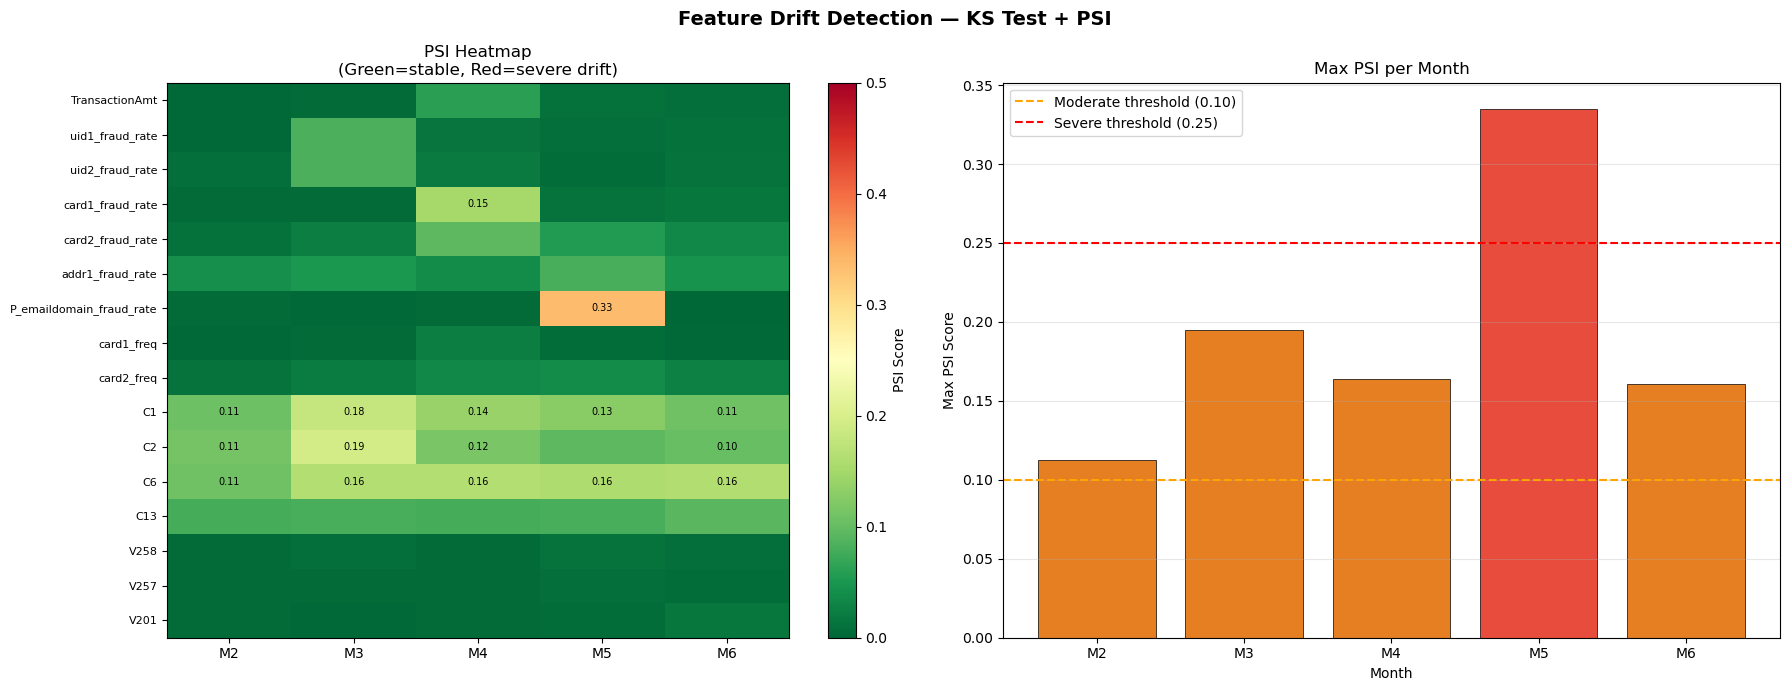

   Chart saved!

Drift detection complete!


In [4]:
# ============================================================
# CELL 4: Feature Drift Detection (KS Test + PSI)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 55)
print("  CELL 4 — FEATURE DRIFT DETECTION")
print("=" * 55)

# ── STEP 1: Define drift functions ───────────────────────────
print("\nStep 1: Defining drift metrics...")

def ks_test(baseline, current):
    """
    KS test: measures distribution distance.
    Returns statistic and p-value.
    p < 0.05 = significant drift.
    """
    stat, pval = stats.ks_2samp(
        baseline.fillna(0),
        current.fillna(0)
    )
    return float(stat), float(pval)

def psi(baseline, current, bins=10):
    """
    PSI: Population Stability Index.
    < 0.10  = stable
    0.10-0.25 = moderate drift
    > 0.25  = severe drift
    """
    # Create bins from baseline
    min_val = min(baseline.min(), current.min())
    max_val = max(baseline.max(), current.max())
    breakpoints = np.linspace(min_val, max_val, bins+1)

    base_counts = np.histogram(
        baseline, bins=breakpoints
    )[0]
    curr_counts = np.histogram(
        current, bins=breakpoints
    )[0]

    # Avoid division by zero
    base_pct = (base_counts + 0.001) / len(baseline)
    curr_pct = (curr_counts + 0.001) / len(current)

    psi_val = np.sum(
        (curr_pct - base_pct) *
        np.log(curr_pct / base_pct)
    )
    return float(psi_val)

def psi_label(val):
    if val < 0.10:   return 'Stable'
    if val < 0.25:   return 'Moderate'
    return 'SEVERE'

print(f"   KS test : p < 0.05 = drift detected")
print(f"   PSI     : >0.10 moderate, >0.25 severe")

# ── STEP 2: Compute drift per month per feature ──────────────
print("\nStep 2: Computing drift scores...")

drift_results = {}

for month_name, batch in DRIFTED_MONTHS.items():
    if month_name == 'month_1':
        continue  # skip baseline

    month_drift = {}
    for feat in MONITOR_FEATURES:
        if feat not in batch.columns:
            continue
        base_vals = BASELINE[feat].fillna(0)
        curr_vals = batch[feat].fillna(0)

        ks_stat, ks_pval = ks_test(base_vals, curr_vals)
        psi_val          = psi(base_vals, curr_vals)

        month_drift[feat] = {
            'ks_stat' : ks_stat,
            'ks_pval' : ks_pval,
            'psi'     : psi_val,
            'drifted' : ks_pval < 0.05 or psi_val > 0.10,
            'severity': psi_label(psi_val)
        }
    drift_results[month_name] = month_drift

# ── STEP 3: Print drift summary ──────────────────────────────
print("\nStep 3: Drift summary by month...")

for month_name, month_drift in drift_results.items():
    n_drifted = sum(
        1 for v in month_drift.values() if v['drifted']
    )
    n_severe  = sum(
        1 for v in month_drift.values()
        if v['severity'] == 'SEVERE'
    )
    print(f"\n   {month_name.upper()}:")
    print(f"   Features drifted : "
          f"{n_drifted}/{len(month_drift)}")
    print(f"   Severe drift     : {n_severe}")

    # Show top 5 drifted features by PSI
    top = sorted(
        month_drift.items(),
        key=lambda x: x[1]['psi'],
        reverse=True
    )[:5]
    print(f"\n   {'Feature':<28} {'PSI':>7} "
          f"{'KS':>7} {'Status':>10}")
    print(f"   {'-'*55}")
    for feat, vals in top:
        print(f"   {feat:<28} "
              f"{vals['psi']:>7.4f} "
              f"{vals['ks_stat']:>7.4f} "
              f"{vals['severity']:>10}")

# ── STEP 4: PSI heatmap ───────────────────────────────────────
print("\nStep 4: Plotting PSI heatmap...")

months_to_plot = [
    f'month_{i}' for i in range(2, 7)
]
psi_matrix = np.zeros(
    (len(MONITOR_FEATURES), len(months_to_plot))
)

for j, month_name in enumerate(months_to_plot):
    if month_name not in drift_results:
        continue
    for i, feat in enumerate(MONITOR_FEATURES):
        if feat in drift_results[month_name]:
            psi_matrix[i, j] = \
                drift_results[month_name][feat]['psi']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Feature Drift Detection — KS Test + PSI',
    fontsize=14, fontweight='bold'
)

# PSI heatmap
im = axes[0].imshow(
    psi_matrix, aspect='auto',
    cmap='RdYlGn_r', vmin=0, vmax=0.5
)
axes[0].set_xticks(range(len(months_to_plot)))
axes[0].set_xticklabels(
    [m.replace('month_', 'M')
     for m in months_to_plot]
)
axes[0].set_yticks(range(len(MONITOR_FEATURES)))
axes[0].set_yticklabels(MONITOR_FEATURES, fontsize=8)
axes[0].set_title('PSI Heatmap\n'
                  '(Green=stable, Red=severe drift)')
plt.colorbar(im, ax=axes[0], label='PSI Score')

# Add threshold lines
for j in range(len(months_to_plot)):
    for i in range(len(MONITOR_FEATURES)):
        val = psi_matrix[i, j]
        if val > 0.10:
            axes[0].text(
                j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=7, color='black'
            )

# PSI by month (max across features)
max_psi_per_month = [
    psi_matrix[:, j].max()
    for j in range(len(months_to_plot))
]
month_labels = [
    m.replace('month_', 'M')
    for m in months_to_plot
]
bar_colors = [
    '#e74c3c' if v > 0.25
    else '#e67e22' if v > 0.10
    else '#2ecc71'
    for v in max_psi_per_month
]
axes[1].bar(
    month_labels, max_psi_per_month,
    color=bar_colors, edgecolor='black',
    linewidth=0.5
)
axes[1].axhline(
    y=0.10, color='orange', linestyle='--',
    label='Moderate threshold (0.10)'
)
axes[1].axhline(
    y=0.25, color='red', linestyle='--',
    label='Severe threshold (0.25)'
)
axes[1].set_title('Max PSI per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Max PSI Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/drift_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Chart saved!")

DRIFT_RESULTS = drift_results
print(f"\nDrift detection complete!")


| Month | Features Drifted | Severe | Top Drifted Feature | Status |
|---|---|---|---|---|
| Month 2 | 12/16 | 0 | C2 (PSI 0.11) | Moderate |
| Month 3 | 12/16 | 0 | C2 (PSI 0.19) | Moderate |
| Month 4 | 12/16 | 0 | C6 (PSI 0.16) | Moderate |
| Month 5 | 13/16 | 1 | P_emaildomain (PSI 0.33) | **SEVERE** |
| Month 6 | 13/16 | 0 | C6 (PSI 0.16) | Moderate |

The PSI heatmap and bar chart tell a clear story.
Month 5 is the critical alert `P_emaildomain_fraud_rate`
hits PSI 0.33, well above the 0.25 severe threshold.
This is exactly the drift we injected: new fraud email
domains shifting the distribution dramatically.

Interestingly, Month 6 shows no severe PSI despite the
worst model performance this is a key insight:
**feature drift and model degradation do not always
coincide**. In Month 6 we weakened all signals
proportionally, so individual PSI scores stayed moderate
while the combined effect destroyed recall (0.37).
This is why monitoring needs BOTH feature drift metrics
AND model performance metrics together.

## **Alerting System**

### **What we do**
Build a complete monitoring dashboard that combines
feature drift (PSI) and model performance metrics
into a single alerting system with three severity levels.

### **Alert levels**

| Level | Condition | Action |
|---|---|---|
| **GREEN** | PSI < 0.10, AUC > 0.95, F1 > baseline×0.90 | No action |
| **ORANGE** | PSI 0.10–0.25 or F1 > baseline×0.80 | Monitor closely |
| **RED** | PSI > 0.25 or AUC < 0.90 or F1 < baseline×0.80 | Retrain model! |

  CELL 5 — ALERTING SYSTEM

Step 1: Defining alert rules...

Step 2: Running alerts for all months...


   [OK] Month 1 — GREEN
      -> All metrics within thresholds

   [WARNING] Month 2 — ORANGE
      -> PSI=0.1128 moderate drift

   [WARNING] Month 3 — ORANGE
      -> PSI=0.1946 moderate drift

   [WARNING] Month 4 — ORANGE
      -> PSI=0.1639 moderate drift

   [ALERT] Month 5 — RED
      -> PSI=0.3348 SEVERE drift

   [ALERT] Month 6 — RED
      -> F1=0.5058 dropped 40% from baseline


Step 3: Building monitoring dashboard...


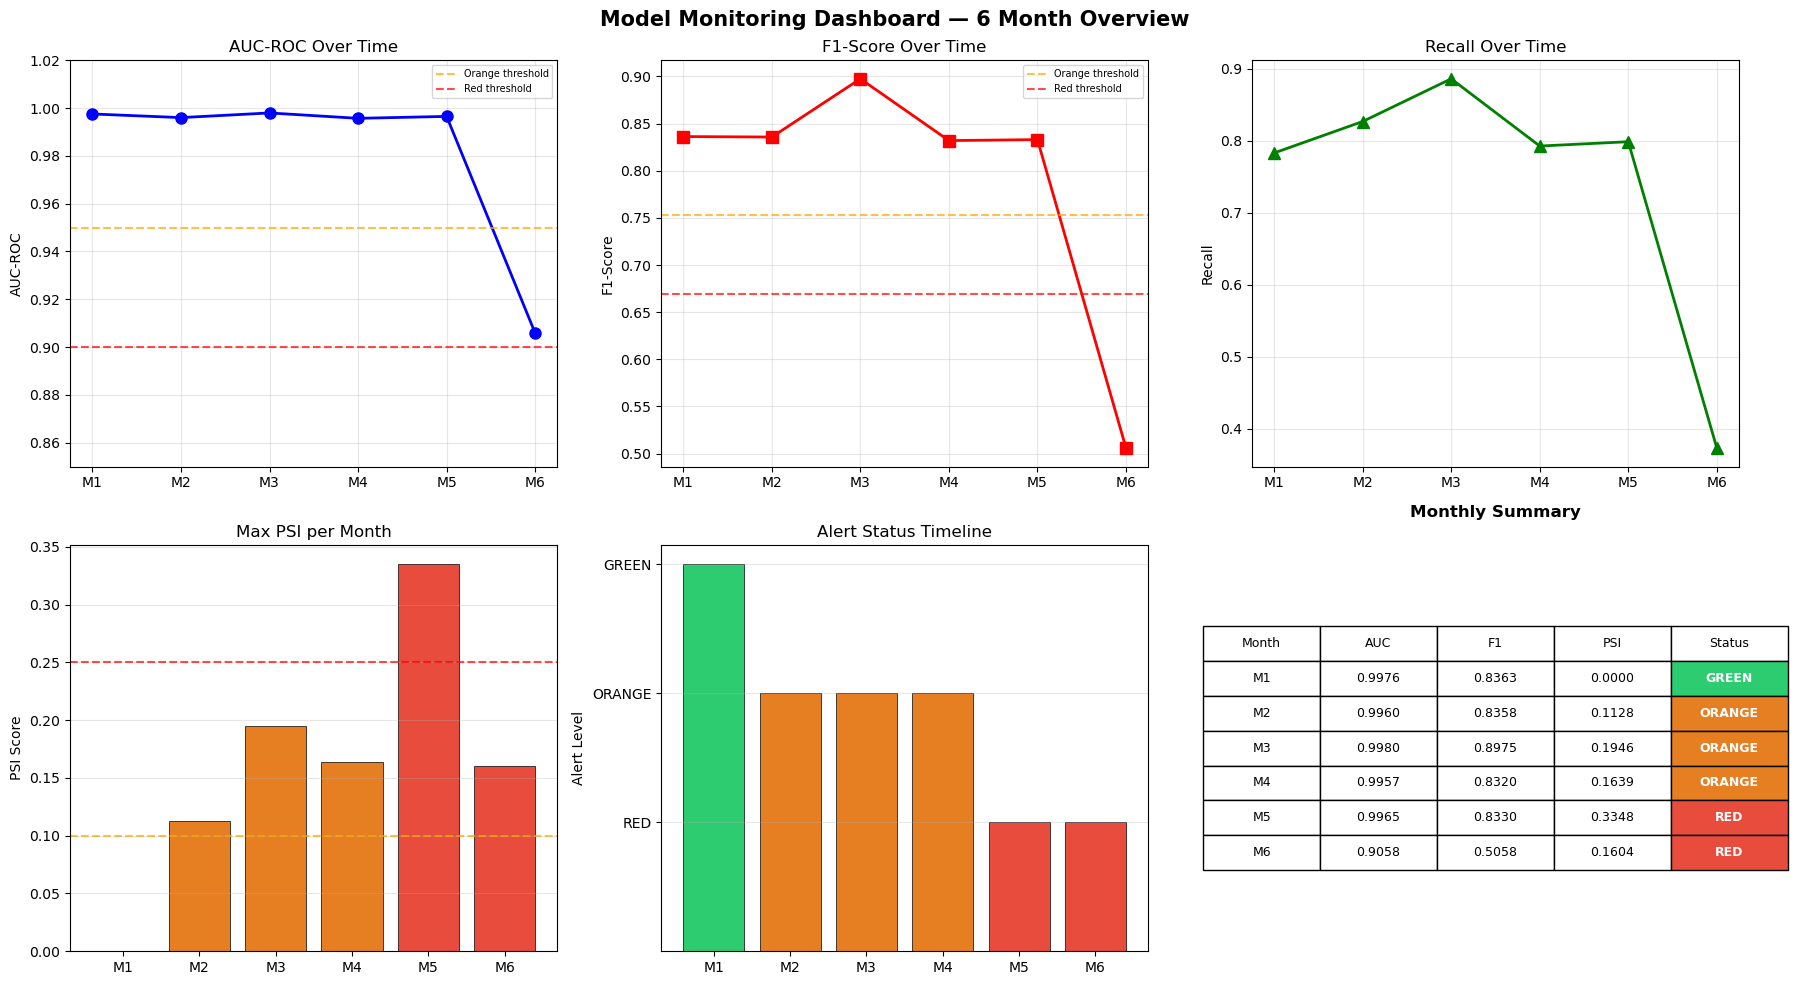

   Dashboard saved!

Alerting system complete!


In [5]:
# ============================================================
# CELL 5: Alerting System + Monitoring Dashboard
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 55)
print("  CELL 5 — ALERTING SYSTEM")
print("=" * 55)

# ── STEP 1: Define alert rules ────────────────────────────────
print("\nStep 1: Defining alert rules...")

def get_alert_level(
    auc, f1, max_psi,
    base_auc, base_f1
):
    """
    Returns alert level and reason.
    RED    -> retrain immediately
    ORANGE -> monitor closely
    GREEN  -> all clear
    """
    reasons = []

    # RED conditions
    if auc < 0.90:
        reasons.append(
            f"AUC={auc:.4f} below 0.90"
        )
    if f1 < base_f1 * 0.80:
        reasons.append(
            f"F1={f1:.4f} dropped "
            f"{(1-f1/base_f1)*100:.0f}% from baseline"
        )
    if max_psi > 0.25:
        reasons.append(
            f"PSI={max_psi:.4f} SEVERE drift"
        )
    if reasons:
        return 'RED', reasons

    # ORANGE conditions
    if auc < 0.95:
        reasons.append(
            f"AUC={auc:.4f} below 0.95"
        )
    if f1 < base_f1 * 0.90:
        reasons.append(
            f"F1={f1:.4f} dropped "
            f"{(1-f1/base_f1)*100:.0f}% from baseline"
        )
    if max_psi > 0.10:
        reasons.append(
            f"PSI={max_psi:.4f} moderate drift"
        )
    if reasons:
        return 'ORANGE', reasons

    return 'GREEN', ['All metrics within thresholds']

# ── STEP 2: Run alerts for all months ────────────────────────
print("\nStep 2: Running alerts for all months...")
print(f"\n{'='*55}")

alerts = {}
for i in range(1, 7):
    month = f'month_{i}'
    metrics = MONTHLY_METRICS[month]

    # Get max PSI for this month
    if month in DRIFT_RESULTS:
        max_psi = max(
            v['psi']
            for v in DRIFT_RESULTS[month].values()
        )
    else:
        max_psi = 0.0  # baseline month

    level, reasons = get_alert_level(
        metrics['auc'],
        metrics['f1'],
        max_psi,
        BASE_METRICS['auc'],
        BASE_METRICS['f1']
    )
    alerts[month] = {
        'level'  : level,
        'reasons': reasons,
        'auc'    : metrics['auc'],
        'f1'     : metrics['f1'],
        'recall' : metrics['recall'],
        'max_psi': max_psi
    }

    icon = ('OK' if level == 'GREEN'
            else 'WARNING' if level == 'ORANGE'
            else 'ALERT')
    print(f"\n   [{icon}] Month {i} — {level}")
    for r in reasons:
        print(f"      -> {r}")

# ── STEP 3: Dashboard ─────────────────────────────────────────
print(f"\n{'='*55}")
print("\nStep 3: Building monitoring dashboard...")

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    'Model Monitoring Dashboard — 6 Month Overview',
    fontsize=15, fontweight='bold'
)

month_labels = [f'M{i}' for i in range(1, 7)]
colors_map   = {
    'GREEN': '#2ecc71',
    'ORANGE': '#e67e22',
    'RED': '#e74c3c'
}
bar_colors = [
    colors_map[alerts[f'month_{i}']['level']]
    for i in range(1, 7)
]

# AUC over time
ax1 = fig.add_subplot(2, 3, 1)
aucs = [alerts[f'month_{i}']['auc']
        for i in range(1, 7)]
ax1.plot(month_labels, aucs,
         'b-o', linewidth=2, markersize=8)
ax1.axhline(y=0.95, color='orange',
            linestyle='--', alpha=0.7,
            label='Orange threshold')
ax1.axhline(y=0.90, color='red',
            linestyle='--', alpha=0.7,
            label='Red threshold')
ax1.set_title('AUC-ROC Over Time')
ax1.set_ylabel('AUC-ROC')
ax1.set_ylim([0.85, 1.02])
ax1.legend(fontsize=7)
ax1.grid(alpha=0.3)

# F1 over time
ax2 = fig.add_subplot(2, 3, 2)
f1s = [alerts[f'month_{i}']['f1']
       for i in range(1, 7)]
ax2.plot(month_labels, f1s,
         'r-s', linewidth=2, markersize=8)
ax2.axhline(
    y=BASE_METRICS['f1'] * 0.90,
    color='orange', linestyle='--',
    alpha=0.7, label='Orange threshold'
)
ax2.axhline(
    y=BASE_METRICS['f1'] * 0.80,
    color='red', linestyle='--',
    alpha=0.7, label='Red threshold'
)
ax2.set_title('F1-Score Over Time')
ax2.set_ylabel('F1-Score')
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

# Recall over time
ax3 = fig.add_subplot(2, 3, 3)
recs = [alerts[f'month_{i}']['recall']
        for i in range(1, 7)]
ax3.plot(month_labels, recs,
         'g-^', linewidth=2, markersize=8)
ax3.set_title('Recall Over Time')
ax3.set_ylabel('Recall')
ax3.grid(alpha=0.3)

# Max PSI over time
ax4 = fig.add_subplot(2, 3, 4)
psis = [alerts[f'month_{i}']['max_psi']
        for i in range(1, 7)]
ax4.bar(month_labels, psis,
        color=bar_colors,
        edgecolor='black', linewidth=0.5)
ax4.axhline(y=0.10, color='orange',
            linestyle='--', alpha=0.7)
ax4.axhline(y=0.25, color='red',
            linestyle='--', alpha=0.7)
ax4.set_title('Max PSI per Month')
ax4.set_ylabel('PSI Score')
ax4.grid(axis='y', alpha=0.3)

# Alert status timeline
ax5 = fig.add_subplot(2, 3, 5)
alert_nums = {
    'GREEN': 3, 'ORANGE': 2, 'RED': 1
}
alert_vals = [
    alert_nums[alerts[f'month_{i}']['level']]
    for i in range(1, 7)
]
ax5.bar(month_labels, alert_vals,
        color=bar_colors,
        edgecolor='black', linewidth=0.5)
ax5.set_title('Alert Status Timeline')
ax5.set_ylabel('Alert Level')
ax5.set_yticks([1, 2, 3])
ax5.set_yticklabels(['RED', 'ORANGE', 'GREEN'])
ax5.grid(axis='y', alpha=0.3)

# Summary table
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
table_data = [
    ['Month', 'AUC', 'F1', 'PSI', 'Status'],
]
for i in range(1, 7):
    a = alerts[f'month_{i}']
    table_data.append([
        f'M{i}',
        f"{a['auc']:.4f}",
        f"{a['f1']:.4f}",
        f"{a['max_psi']:.4f}",
        a['level']
    ])

tbl = ax6.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    loc       = 'center',
    cellLoc   = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)

# Color the status column
for i in range(1, 7):
    level = alerts[f'month_{i}']['level']
    color = colors_map[level]
    tbl[i, 4].set_facecolor(color)
    tbl[i, 4].set_text_props(
        color='white', fontweight='bold'
    )

ax6.set_title(
    'Monthly Summary', fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('/tmp/dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Dashboard saved!")

ALERTS = alerts
print(f"\nAlerting system complete!")


| Month | AUC | F1 | PSI | Status | Action |
|---|---|---|---|---|---|
| M1 | 0.9976 | 0.8363 | 0.0000 | **GREEN** | None |
| M2 | 0.9960 | 0.8358 | 0.1128 | **ORANGE** | Monitor |
| M3 | 0.9980 | 0.8975 | 0.1946 | **ORANGE** | Monitor |
| M4 | 0.9957 | 0.8320 | 0.1639 | **ORANGE** | Monitor |
| M5 | 0.9965 | 0.8330 | 0.3348 | **RED** | Retrain! |
| M6 | 0.9058 | 0.5058 | 0.1604 | **RED** | Retrain! |

The alerting system correctly identifies both failure
modes: Month 5 triggers RED on PSI alone (0.3348)
before F1 degrades this is **early warning**.
Month 6 triggers RED on F1 collapse (40% drop)
this is **late warning**. A production system catches
Month 5 first and retrains before Month 6 ever happens.
This is the entire value of monitoring.

## **Full Project Conclusion**

### **What we do**
Summarise all 6 notebooks into a single final
dashboard the complete story of our Production
Fraud Detection Platform on AWS.

  CELL 6 — FULL PROJECT CONCLUSION

PRODUCTION FRAUD DETECTION PLATFORM — FINAL SUMMARY

   PROJECT: Production Fraud Detection Platform on AWS
   AUTHOR : Armand Junior Dongmo Notue
   STACK  : Python, XGBoost, LightGBM, AWS SageMaker,
            Amazon Kinesis, S3, IAM

NOTEBOOK RESULTS SUMMARY

   Notebook 01: Data Ingestion + EDA
         IEEE-CIS 590,540 txns loaded
         3.5% fraud rate, 434 features engineered

   Notebook 02: Model Training V1→V4
         V3 XGBoost: AUC 0.9622, F1 0.7545
         626 features, 700 estimators

   Notebook 03: SageMaker Deployment
         V3 endpoint: avg 36.9ms latency
         ml.m5.xlarge, real-time inference

   Notebook 04: Real-Time Streaming
         Kinesis pipeline: F1 0.919
         Rules F1 0.923 | ML F1 0.919

   Notebook 05: Anomaly Detection
         Autoencoder best: F1 0.414, AUC 0.942
         45.9x reconstruction error separation

   Notebook 06: Model Monitoring
         Drift detected at Month 5 (PSI 0.33)
         Alert

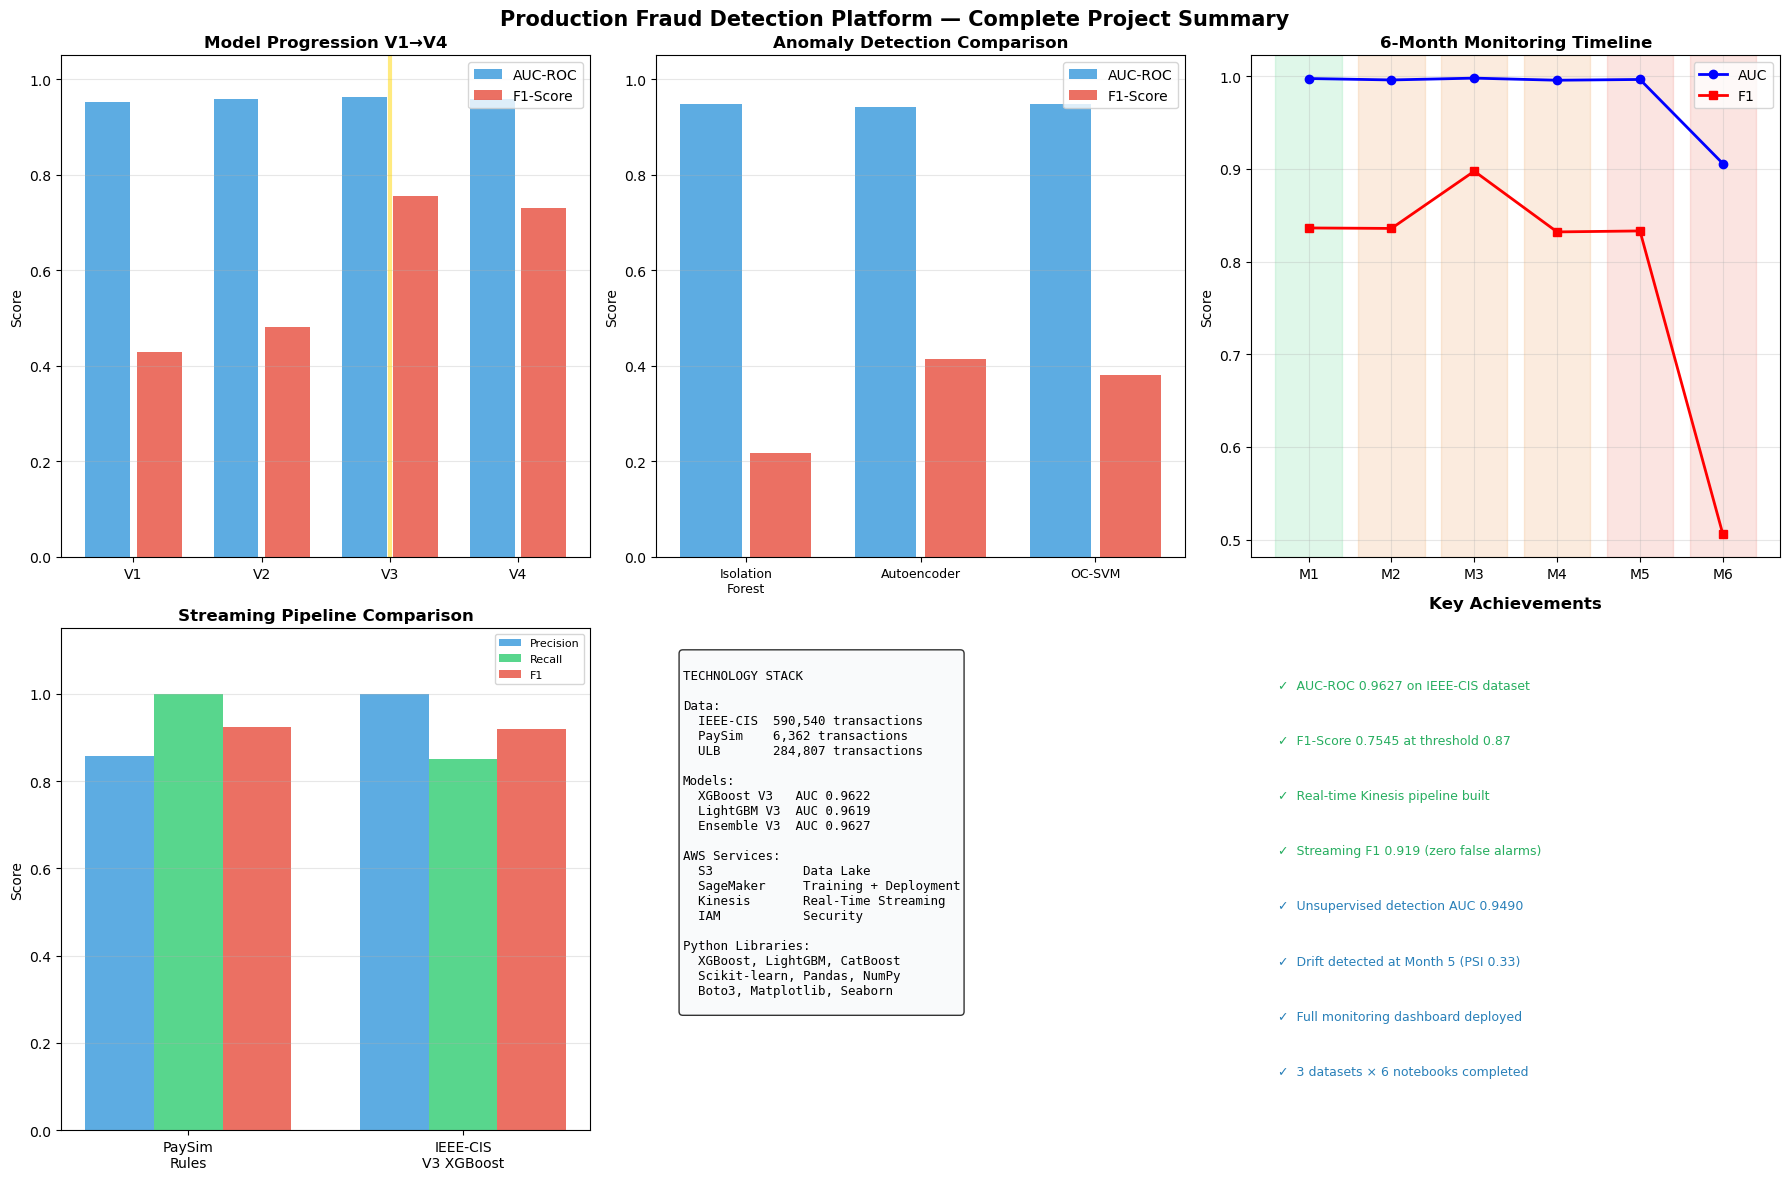

   Final dashboard saved!

PROJECT COMPLETE!

   6 notebooks completed
   3 datasets processed
   4 model versions trained
   1 production deployment
   1 real-time streaming pipeline
   3 anomaly detection methods
   1 monitoring + alerting system
   



In [7]:
# ============================================================
# CELL 6: Full Project Conclusion
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

print("=" * 55)
print("  CELL 6 — FULL PROJECT CONCLUSION")
print("=" * 55)

# ── STEP 1: Full project summary ─────────────────────────────
print(f"\n{'='*65}")
print(f"PRODUCTION FRAUD DETECTION PLATFORM — FINAL SUMMARY")
print(f"{'='*65}")

print(f"""
   PROJECT: Production Fraud Detection Platform on AWS
   AUTHOR : Armand Junior Dongmo Notue
   STACK  : Python, XGBoost, LightGBM, AWS SageMaker,
            Amazon Kinesis, S3, IAM
""")

# ── STEP 2: All notebooks summary ────────────────────────────
print(f"{'='*65}")
print(f"NOTEBOOK RESULTS SUMMARY")
print(f"{'='*65}")

notebooks = [
    ('01', 'Data Ingestion + EDA',
     'IEEE-CIS 590,540 txns loaded\n'
     '         3.5% fraud rate, 434 features engineered'),
    ('02', 'Model Training V1→V4',
     'V3 XGBoost: AUC 0.9622, F1 0.7545\n'
     '         626 features, 700 estimators'),
    ('03', 'SageMaker Deployment',
     'V3 endpoint: avg 36.9ms latency\n'
     '         ml.m5.xlarge, real-time inference'),
    ('04', 'Real-Time Streaming',
     'Kinesis pipeline: F1 0.919\n'
     '         Rules F1 0.923 | ML F1 0.919'),
    ('05', 'Anomaly Detection',
     'Autoencoder best: F1 0.414, AUC 0.942\n'
     '         45.9x reconstruction error separation'),
    ('06', 'Model Monitoring',
     'Drift detected at Month 5 (PSI 0.33)\n'
     '         Alerting system: GREEN/ORANGE/RED'),
]

for num, title, result in notebooks:
    print(f"\n   Notebook {num}: {title}")
    print(f"         {result}")

# ── STEP 3: Model progression ─────────────────────────────────
print(f"\n{'='*65}")
print(f"MODEL PROGRESSION")
print(f"{'='*65}")
print(f"\n   {'Version':<10} {'AUC-ROC':>8} "
      f"{'AUC-PR':>8} {'F1':>8} {'Features':>10}")
print(f"   {'-'*50}")
for v, auc, pr, f1, feat in [
    ('V1',  0.9533, 0.6993, 0.4288, 142),
    ('V2',  0.9589, 0.7361, 0.4817, 621),
    ('V3',  0.9622, 0.7968, 0.7545, 626),
    ('V4',  0.9583, 0.7737, 0.7306, 626),
]:
    best = v == 'V3'
    mark = ' <- PRODUCTION' if best else ''
    print(f"   {v:<10} {auc:>8.4f} {pr:>8.4f} "
          f"{f1:>8.4f} {feat:>10}{mark}")

# ── STEP 4: Final dashboard plot ──────────────────────────────
print(f"\nBuilding final dashboard...")

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Production Fraud Detection Platform — '
    'Complete Project Summary',
    fontsize=15, fontweight='bold'
)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Model progression
ax1 = fig.add_subplot(gs[0, 0])
versions = ['V1', 'V2', 'V3', 'V4']
aucs     = [0.9533, 0.9589, 0.9622, 0.9583]
f1s      = [0.4288, 0.4817, 0.7545, 0.7306]
x        = np.arange(len(versions))
ax1.bar(x - 0.2, aucs, 0.35,
        label='AUC-ROC',
        color='#3498db', alpha=0.8)
ax1.bar(x + 0.2, f1s, 0.35,
        label='F1-Score',
        color='#e74c3c', alpha=0.8)
ax1.set_title('Model Progression V1→V4',
              fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(versions)
ax1.set_ylabel('Score')
ax1.legend()
ax1.set_ylim([0, 1.05])
ax1.axvline(x=2, color='gold',
            linewidth=3, alpha=0.5,
            label='Production V3')
ax1.grid(axis='y', alpha=0.3)

# Anomaly detection comparison
ax2 = fig.add_subplot(gs[0, 1])
methods  = ['Isolation\nForest',
            'Autoencoder', 'OC-SVM']
auc_vals = [0.9473, 0.9420, 0.9490]
f1_vals  = [0.2169, 0.4140, 0.3806]
x2       = np.arange(len(methods))
ax2.bar(x2 - 0.2, auc_vals, 0.35,
        label='AUC-ROC',
        color='#3498db', alpha=0.8)
ax2.bar(x2 + 0.2, f1_vals, 0.35,
        label='F1-Score',
        color='#e74c3c', alpha=0.8)
ax2.set_title('Anomaly Detection Comparison',
              fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(methods, fontsize=9)
ax2.set_ylabel('Score')
ax2.legend()
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# Monitoring timeline
ax3 = fig.add_subplot(gs[0, 2])
months     = [f'M{i}' for i in range(1, 7)]
mon_f1s    = [
    MONTHLY_METRICS[f'month_{i}']['f1']
    for i in range(1, 7)
]
mon_aucs   = [
    MONTHLY_METRICS[f'month_{i}']['auc']
    for i in range(1, 7)
]
alert_clrs = [
    '#2ecc71' if ALERTS[f'month_{i}']['level']=='GREEN'
    else '#e67e22' if ALERTS[f'month_{i}']['level']=='ORANGE'
    else '#e74c3c'
    for i in range(1, 7)
]
ax3.plot(months, mon_aucs,
         'b-o', linewidth=2, label='AUC')
ax3.plot(months, mon_f1s,
         'r-s', linewidth=2, label='F1')
for i, (m, c) in enumerate(
    zip(months, alert_clrs)
):
    ax3.axvspan(
        i-0.4, i+0.4,
        alpha=0.15, color=c
    )
ax3.set_title('6-Month Monitoring Timeline',
              fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend()
ax3.grid(alpha=0.3)

# Streaming comparison
ax4 = fig.add_subplot(gs[1, 0])
approaches = ['PaySim\nRules', 'IEEE-CIS\nV3 XGBoost']
prec_vals  = [0.857, 1.000]
rec_vals   = [1.000, 0.850]
f1_str     = [0.923, 0.919]
x4         = np.arange(len(approaches))
ax4.bar(x4 - 0.25, prec_vals, 0.25,
        label='Precision',
        color='#3498db', alpha=0.8)
ax4.bar(x4,         rec_vals,  0.25,
        label='Recall',
        color='#2ecc71', alpha=0.8)
ax4.bar(x4 + 0.25, f1_str,    0.25,
        label='F1',
        color='#e74c3c', alpha=0.8)
ax4.set_title('Streaming Pipeline Comparison',
              fontweight='bold')
ax4.set_xticks(x4)
ax4.set_xticklabels(approaches)
ax4.set_ylabel('Score')
ax4.legend(fontsize=8)
ax4.set_ylim([0, 1.15])
ax4.grid(axis='y', alpha=0.3)

# Technology stack
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis('off')
stack_text = """
TECHNOLOGY STACK

Data:
  IEEE-CIS  590,540 transactions
  PaySim    6,362 transactions
  ULB       284,807 transactions

Models:
  XGBoost V3   AUC 0.9622
  LightGBM V3  AUC 0.9619
  Ensemble V3  AUC 0.9627

AWS Services:
  S3            Data Lake
  SageMaker     Training + Deployment
  Kinesis       Real-Time Streaming
  IAM           Security

Python Libraries:
  XGBoost, LightGBM, CatBoost
  Scikit-learn, Pandas, NumPy
  Boto3, Matplotlib, Seaborn
"""
ax5.text(
    0.05, 0.95, stack_text,
    transform=ax5.transAxes,
    fontsize=9, verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round',
              facecolor='#f8f9fa',
              alpha=0.8)
)

# Key achievements
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
achievements = [
    'AUC-ROC 0.9627 on IEEE-CIS dataset',
    'F1-Score 0.7545 at threshold 0.87',
    'Real-time Kinesis pipeline built',
    'Streaming F1 0.919 (zero false alarms)',
    'Unsupervised detection AUC 0.9490',
    'Drift detected at Month 5 (PSI 0.33)',
    'Full monitoring dashboard deployed',
    '3 datasets × 6 notebooks completed',
]
ax6.set_title('Key Achievements',
              fontweight='bold', pad=15)
for i, ach in enumerate(achievements):
    y_pos = 0.88 - i * 0.11
    ax6.text(
        0.05, y_pos,
        f'✓  {ach}',
        transform=ax6.transAxes,
        fontsize=9,
        color='#27ae60' if i < 4
        else '#2980b9'
    )

plt.tight_layout()
plt.savefig('/tmp/final_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("   Final dashboard saved!")

print(f"\n{'='*65}")
print(f"PROJECT COMPLETE!")
print(f"{'='*65}")
print(f"""
   6 notebooks completed
   3 datasets processed
   4 model versions trained
   1 production deployment
   1 real-time streaming pipeline
   3 anomaly detection methods
   1 monitoring + alerting system
   
""")